In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from grb.io import read_data, filter_data
from grb.const import TRIGGER_TIME
from grb.analysis import Analyzer

from grb.functions import *
from grb.prior import *
from grb.extinction import host_galaxy_extinction, host_galaxy_extinction_curve

In [4]:
df_sdt = read_data("sdt", correct_galactic_extinction=True, add_converted_flux=True)
x0 = pivot_finder(df_sdt["frequency_Hz"], df_sdt["flux_mJy"], df_sdt["flux_error_mJy"])
print(x0/1e14)

Optimal Pivot: 5.90e+14
5.903434426266961


In [5]:
host_galaxy_extinction_curve(df_sdt["frequency_Hz"], z=0.572)

array([1.36808287, 1.07807269, 0.87557649, 1.72843137, 1.55197314,
       1.44724872, 1.36808287, 1.2968336 , 1.23236998, 1.18058997,
       1.14344603, 1.10939742, 1.07807269, 1.04746213, 1.01882637,
       0.98677249, 0.90522876, 0.86840256, 0.833878  , 0.80144583,
       0.77092144, 0.74341737])

## 7DT SED fit

In [3]:
df_sdt = read_data("sdt", correct_galactic_extinction=True, add_converted_flux=True)

eta = host_galaxy_extinction_curve(df_sdt["frequency_Hz"], z=0.572)
print("eta:", eta)
combined_func = lambda x, *params: power_law(x, *params[:2], x0=1e15) * host_galaxy_extinction(x, *params[2:], eta=eta)

param_bounds, prior = power_law_prior(data_type="sed")
param_bounds_ext, prior_ext = host_galaxy_extinction_prior()
param_bounds.update(param_bounds_ext)
prior.update(prior_ext)

alz_sed = Analyzer(df_sdt["frequency_Hz"], df_sdt["flux_mJy"], combined_func, data_type="sed", y_data_error=df_sdt["flux_error_mJy"], x_data_error=df_sdt["frequency_Hz_error"], param_bounds=param_bounds, prior=prior)
alz_sed.run()

/data9/hongyp/GRB251013C/GRB_fitting/grb/extinction.py:45: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  uncorrected_df[magnitude_column] -= extinc
/data9/hongyp/GRB251013C/GRB_fitting/grb/utils.py:36: FutureWarning: ChainedAssignmentError: 

eta: [1.36808287 1.07807269 0.87557649 1.72843137 1.55197314 1.44724872
 1.36808287 1.2968336  1.23236998 1.18058997 1.14344603 1.10939742
 1.07807269 1.04746213 1.01882637 0.98677249 0.90522876 0.86840256
 0.833878   0.80144583 0.77092144 0.74341737]
[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-5e+01   [-52.1671..-52.1671]*| it/evals=4275/107057 eff=4.0044% N=300      00 0 0   
[ultranest] Likelihood function evaluations: 107098
[ultranest]   logZ = -61.82 +- 0.1518
[ultranest] Effective samples strategy satisfied (ESS = 1214.0, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.15, need <0.5)
[ultranest]   logZ error budget: single: 0.17 bs:0.15 tail:0.01 total:0.15 required:<0.50
[ultranest] done iterating.


In [4]:
alz_sed.results

{'niter': 4577,
 'logz': np.float64(-61.80449574701537),
 'logzerr': np.float64(0.3274074889912504),
 'logz_bs': np.float64(-61.81731465091941),
 'logz_single': np.float64(-61.80449574701537),
 'logzerr_tail': np.float64(0.009930146653651661),
 'logzerr_bs': np.float64(0.32725686552766575),
 'ess': np.float64(1213.9773368188967),
 'H': np.float64(8.608874934659873),
 'Herr': np.float64(0.14200500666631238),
 'posterior': {'mean': [0.20145612547886343,
   0.9196491863628609,
   0.1535941484120598],
  'stdev': [0.04491188936032241, 0.12135519777002779, 0.1117191796957024],
  'median': [0.1889130838695567, 0.9361678732631786, 0.1262812006771032],
  'errlo': [0.16558813601814168, 0.8021453926258735, 0.05206198980406113],
  'errup': [0.2360197225533346, 1.0342549984557625, 0.25298374363990256],
  'information_gain_bits': [3.2179216646874838,
   1.5086054741045638,
   -4.691988960664425]},
 'weighted_samples': {'upoints': array([[0.99974366, 0.99940193, 0.24447023],
         [0.97744305, 0.9

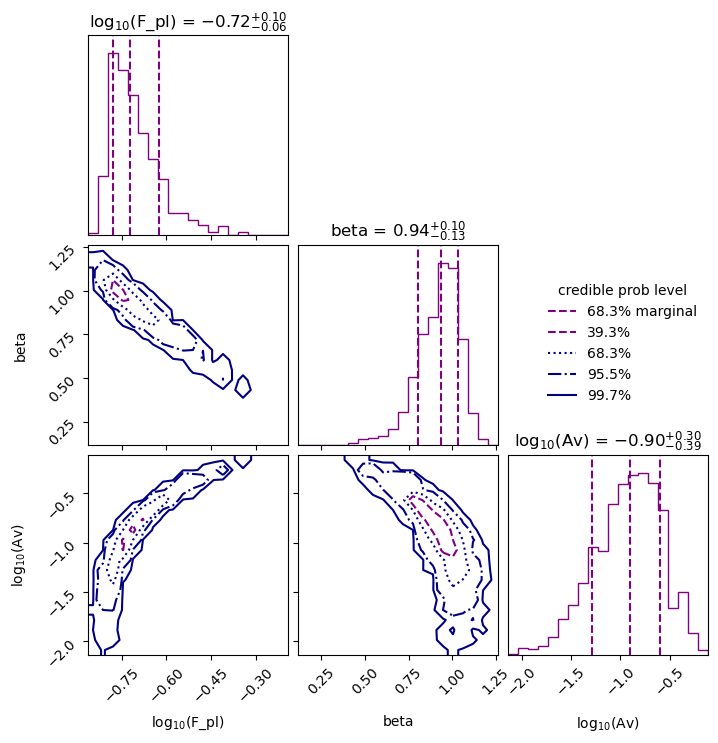

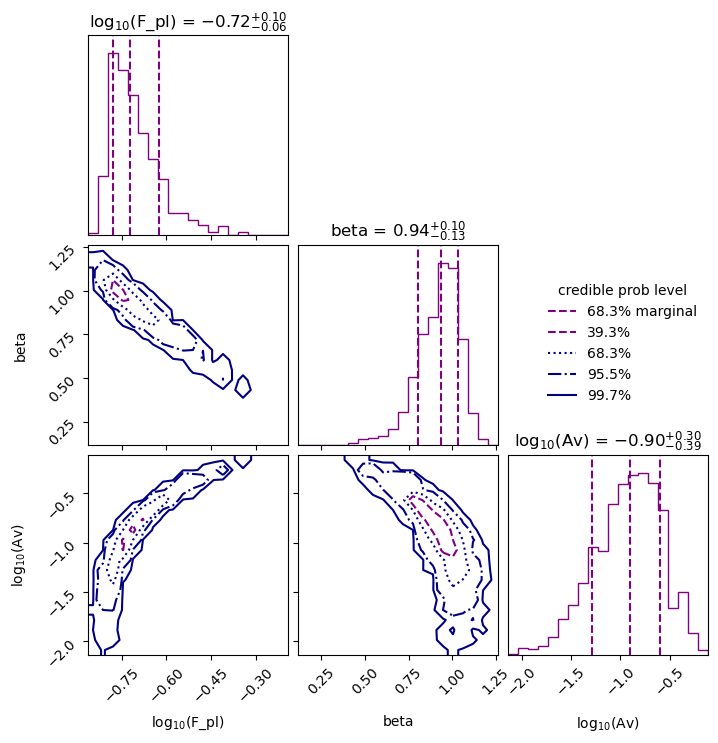

In [5]:
alz_sed.plot_corner()

<Axes: xlabel='Frequency', ylabel='Flux'>

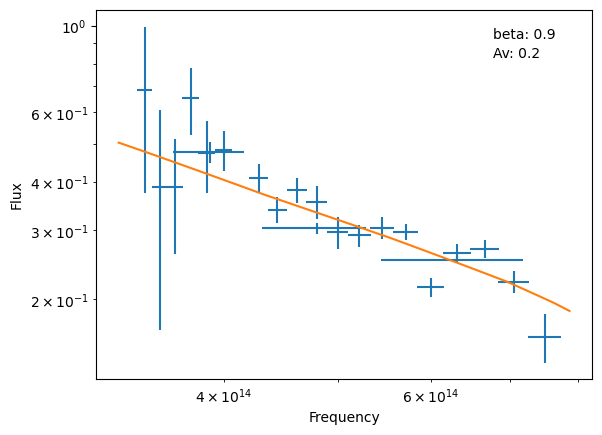

In [6]:
alz_sed.plot_data()
alz_sed.plot_model(show_param=True)


## XRT fit

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from grb.io import read_data, filter_data
from grb.const import TRIGGER_TIME
from grb.analysis import Analyzer

from grb.functions import *
from grb.prior import *

In [2]:
df_xrt = read_data("xrt")
df_filtered = filter_data(df_xrt, exclude_time_range = (3e3,  1e4))
y_err = np.array([max(np.abs(high), np.abs(low)) for high, low in zip(df_filtered["Flux_high"], df_filtered["Flux_low"])])
alz_xrt = Analyzer(df_filtered["Time"][5:]/3600, df_filtered["Flux"][5:], broken_power_law, y_data_error=y_err[5:])
alz_xrt.run()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-1e+01   [-13.3905..-13.3895]*| it/evals=6258/224996 eff=2.7851% N=300   0 0 
[ultranest] Likelihood function evaluations: 225222
[ultranest]   logZ = -29.64 +- 0.1784
[ultranest] Effective samples strategy satisfied (ESS = 2405.7, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.21 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.


In [3]:
alz_xrt.results

{'niter': 6565,
 'logz': -29.612755811718234,
 'logzerr': 0.3902181591274015,
 'logz_bs': -29.641974693773477,
 'logz_single': -29.612755811718234,
 'logzerr_tail': 0.009941461217653824,
 'logzerr_bs': 0.39009150088362077,
 'ess': 2405.6663514381275,
 'H': 13.226180426211783,
 'Herr': 0.14237974297006814,
 'posterior': {'mean': [5.170041287728977e-11,
   2.2578455293634216,
   1.506255343938115,
   1.0085610495837856],
  'stdev': [3.190004652731437e-11,
   11.186318548670355,
   0.9795842044293481,
   0.1280637756482418],
  'median': [4.882175374031539e-11,
   0.31008868967804126,
   1.5385863457129858,
   1.0106266640413315],
  'errlo': [2.7429424645647884e-11,
   0.22821926926416405,
   1.2743813872555059,
   0.9694000717371533],
  'errup': [7.029519931667092e-11,
   0.4998800468841254,
   1.8992215038080735,
   1.0468836025013961],
  'information_gain_bits': [2.2948687462958786,
   -3.3190672957289395,
   -2.7530300768076006,
   0.9255123977309764]},
 'weighted_samples': {'upoints':

In [4]:
import pickle
import os

all_results = {}

analyzers = {
    "sed": ("alz_sed", "sed"),
    "xrt": ("alz_xrt", "lightcurve"),
    "Ic": ("alz_Ic", "lightcurve"),
    "i": ("alz_i", "lightcurve"),
    "Rc": ("alz_Rc", "lightcurve"),
    "r": ("alz_r", "lightcurve"),
    "g": ("alz_g", "lightcurve"),
}

for name, (var_name, data_type) in analyzers.items():
    alz = globals().get(var_name)
    if alz is None or alz.results is None:
        print(f"Skipping {name}: not available")
        continue
    all_results[name] = {
        "results": alz.results,
        "best_fit_params": alz.best_fit_params,
        "params": alz.params,
        "x_data": alz.x_data,
        "y_data": alz.y_data,
        "y_data_error": alz.y_data_error,
        "x_data_error": getattr(alz, "x_data_error", None),
        "data_type": data_type,
    }
    print(f"Saved {name}: params={alz.params}, best_fit={alz.best_fit_params}")

output_path = os.path.join(os.getcwd(), "fit_results.pkl")
with open(output_path, "wb") as f:
    pickle.dump(all_results, f)

print(f"\nAll results saved to {output_path}")
print(f"Keys: {list(all_results.keys())}")

Skipping sed: not available
Saved xrt: params=['F_bpl', 't_break', 'alpha_1', 'alpha_2'], best_fit=[4.804188704549557e-11, 0.3156578655258031, 1.575792288137114, 1.0093569303475958]
Skipping Ic: not available
Skipping i: not available
Skipping Rc: not available
Skipping r: not available
Skipping g: not available

All results saved to /data9/hongyp/GRB251013C/GRB_fitting_test/fit_results.pkl
Keys: ['xrt']


<Axes: xlabel='Time', ylabel='Flux'>

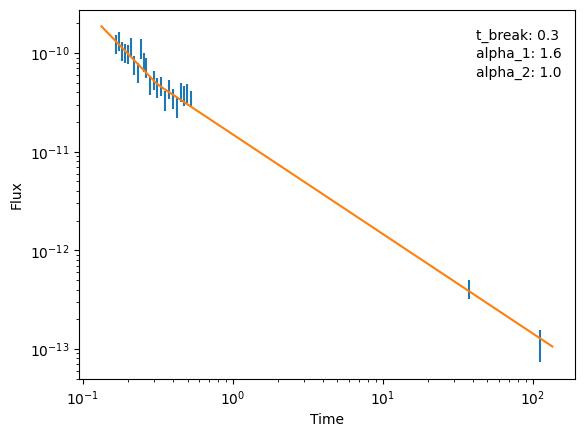

In [6]:
alz_xrt.plot_data()
alz_xrt.plot_model(show_param=True)
# plt.scatter(df["Time"], df["flux_mJy"]/1e7)
# plt.scatter(alz_BBO.x_data, alz_BBO.y_data/1e7)

#plt.plot(df_xrt["Time"]/3600, df_xrt["Flux"])

In [ ]:
from grb.functions import smooth_broken_power_law


df = read_data("circular", add_converted_flux=True)
df = filter_data(df, filter_name=["Rc"], remove_upper_limits=True, facility_name= "Leavitt")

alz_Rc = Analyzer(df["Time"], df["flux_mJy"], power_law, y_data_error=df["flux_error_mJy"])
alz_Rc.run(method="curve_fit")

## Clear filters

In [85]:
df = read_data("circular", add_converted_flux=True)
filtered_df = filter_data(df, remove_upper_limits=True, facility_name= "BOOTES-6/DPRT")
alz_BBO = Analyzer(filtered_df["Time"], filtered_df["flux_mJy"], power_law, y_data_error=filtered_df["flux_error_mJy"])
alz_BBO.run(method="curve_fit")

<Axes: xlabel='Time', ylabel='Flux'>

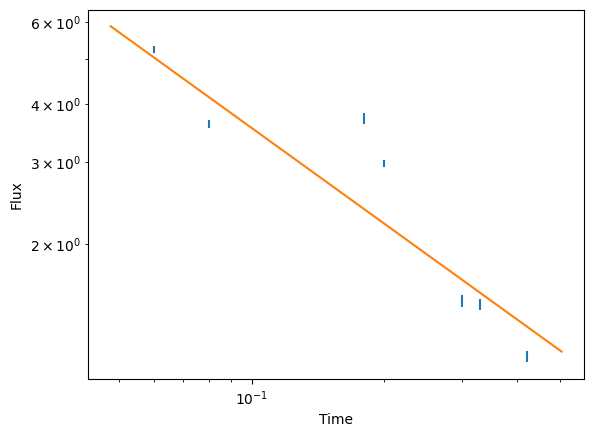

In [86]:
alz_BBO.plot_data()
alz_BBO.plot_model()

In [57]:
df = read_data("circular", add_converted_flux=True)
filtered_df = filter_data(df, remove_upper_limits=True, facility_name= "Calapai")
alz_calapai = Analyzer(filtered_df["Time"], filtered_df["flux_mJy"], broken_power_law, y_data_error=filtered_df["flux_error_mJy"])
alz_calapai.run(method="ultranest")
print(alz_calapai.best_fit_params)

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-5e+02  .25 [-534.4413..-534.4411]*| it/evals=9330/436061 eff=2.1388% N=290    0   0   
[ultranest] Likelihood function evaluations: 436097
[ultranest]   logZ = -561.9 +- 0.1845
[ultranest] Effective samples strategy satisfied (ESS = 1698.4, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.30 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.
[0.31883678612492183, 5.16032318449346, 1.2753034173656008, 2.0703314407716524]


## Ic band fit

In [25]:
df = read_data("circular", add_converted_flux=True)
df = filter_data(df, filter_name=["Ic"], remove_upper_limits=True, facility_name= "Leavitt")
alz_Ic = Analyzer(df["Time"], df["flux_mJy"], broken_power_law, y_data_error=df["flux_error_mJy"])
alz_Ic.run(method="curve_fit")

## i band fit

In [11]:
filter_name = "i"

df = read_data("circular", add_converted_flux=True)
df = filter_data(df, filter_name=filter_name, remove_upper_limits=True)

combined_func = lambda t, *params: power_law(t, *params[:2]) +  broken_power_law(t, *params[2:])

param_bounds, prior = power_law_prior()
param_bounds_bknpl, prior_bknpl = broken_power_law_prior()
param_bounds.update(param_bounds_bknpl)
prior.update(prior_bknpl)
# param_bounds["alpha_d"] = (alz_Ic.results["posterior"]["mean"][1], alz_Ic.results["posterior"]["stdev"][1])
# prior["alpha_d"] = "norm"

alz_i = Analyzer(df["Time"], df["flux_mJy"], combined_func, param_bounds=param_bounds, prior=prior, y_data_error=df["flux_error_mJy"])
alz_i.run(method="curve_fit")

## Rc band fit

In [ ]:
from grb.functions import smooth_broken_power_law


df = read_data("circular", add_converted_flux=True)
df = filter_data(df, filter_name=["Rc"], remove_upper_limits=True, facility_name= "Leavitt")

alz_Rc = Analyzer(df["Time"], df["flux_mJy"], power_law, y_data_error=df["flux_error_mJy"])
alz_Rc.run(method="curve_fit")

## r/ r' bands fit

In [13]:
df = read_data("circular", add_converted_flux=True)
df = filter_data(df, filter_name=["r", "r'"], remove_upper_limits=True, exclude_time_range=(20, 1e4))

alz_r = Analyzer(df["Time"], df["flux_mJy"], broken_power_law, y_data_error=df["flux_error_mJy"])
alz_r.run(method="curve_fit")

## g band fit

In [15]:
df = read_data("circular", add_converted_flux=True)
df = filter_data(df, filter_name=["g"], remove_upper_limits=True, exclude_time_range=(20, 1e4))
alz_g = Analyzer(df["Time"], df["flux_mJy"], power_law, y_data_error=df["flux_error_mJy"])
alz_g.run(method="curve_fit")

In [ ]:
from grb.io import read_data
from datetime import datetime

times = read_data("sdt")["date_obs"]

sdt_min = (datetime.strptime(min(times), "%Y-%m-%dT%H:%M:%S.%f") -TRIGGER_TIME).total_seconds()/3600.
sdt_max = (datetime.strptime(max(times), "%Y-%m-%dT%H:%M:%S.%f")-TRIGGER_TIME).total_seconds()/3600.
sdt_ave = (sdt_min + sdt_max)/2

In [28]:
alz_Ic.best_fit_params

array([ 0.16482339, 14.77391624,  1.16108773,  1.88708998])

In [32]:
alz_calapai.best_fit_params

array([0.45785138, 3.91000321, 1.26203036, 1.50369645])

In [ ]:
from grb.functions import smooth_broken_power_law


df = read_data("circular", add_converted_flux=True)
df = filter_data(df, filter_name=["Rc"], remove_upper_limits=True, facility_name= "Leavitt")

st = 20
alz_Rc = Analyzer(df["Time"][st:], df["flux_mJy"][st:], power_law, y_data_error=df["flux_error_mJy"][st:])
alz_Rc.run(method="curve_fit")

In [ ]:
df = read_data("circular", add_converted_flux=True)
filtered_df = filter_data(df, remove_upper_limits=True, facility_name= "Calapai")
alz_calapai = Analyzer(filtered_df["Time"], filtered_df["flux_mJy"], broken_power_law, y_data_error=filtered_df["flux_error_mJy"])
alz_calapai.run(method="curve_fit")

array([3.23147025, 1.18539978])

[3.23147025 1.18539978]
[ 0.16482339 14.77391624  1.16108773  1.88708998]
[0.45785138 3.91000321 1.26203036 1.50369645]


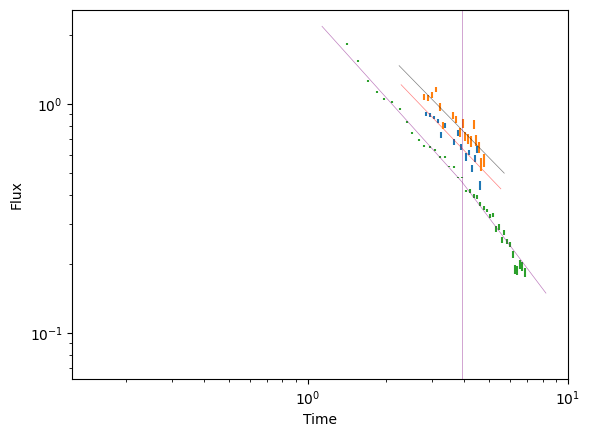

In [54]:
alz_Rc.plot_data(label="Rc")
alz_Rc.plot_model(color="red", lw=0.5, alpha=0.5)
print(alz_Rc.best_fit_params)

alz_Ic.plot_data(label="Ic")
alz_Ic.plot_model(color="black", lw=0.5, alpha=0.5)
print(alz_Ic.best_fit_params)

alz_calapai.plot_data(label="Calapai")
alz_calapai.plot_model(color="purple", lw=0.5, alpha=0.5)
plt.axvline(alz_calapai.best_fit_params[1], color="purple", lw=0.5, alpha=0.5)
print(alz_calapai.best_fit_params)

XRT [1.60936560e-06 1.02740945e+00]
Rc [3.8192547 1.3379497]
Ic [3.75756109 1.16108784]
i [8.43655065e-08 5.00000000e+00 1.23248004e+00 4.52907068e+00
 2.96901891e-01 3.06195092e+00]
Calapai [0.45785138 3.91000321 1.26203036 1.50369645]


(2, 8)

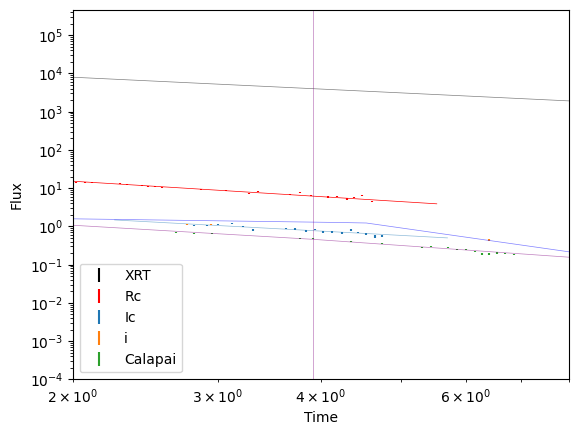

In [23]:
alz_xrt.plot_data(scale=1e10, color="k", label="XRT")
alz_xrt.plot_model(color="k", scale=1e10, lw=0.5, alpha=0.5)
print("XRT", alz_xrt.best_fit_params)

alz_Rc.plot_data(scale=10, color="red", label="Rc")
alz_Rc.plot_model(color="red", scale=10, lw=0.5)
print("Rc", alz_Rc.best_fit_params)

# alz_r.plot_data(scale=10, color="brown", label="r and r'")
# alz_r.plot_model(color="brown", scale=10, lw=0.5)
# plt.axvline(alz_r.best_fit_params[1], color="brown", lw=0.5, alpha=0.5)

alz_Ic.plot_data(label="Ic")
alz_Ic.plot_model(color="C0", lw=0.5, alpha=0.5)
print("Ic", alz_Ic.best_fit_params)

alz_i.plot_data(label="i")
alz_i.plot_model(color="blue", lw=0.5, alpha=0.5)
#plt.axvline(alz_i.best_fit_params[3], color="blue", lw=0.5, alpha=0.5)
print("i", alz_i.best_fit_params)

alz_calapai.plot_data(label="Calapai")
alz_calapai.plot_model(color="purple", lw=0.5, alpha=0.5)
plt.axvline(alz_calapai.best_fit_params[1], color="purple", lw=0.5, alpha=0.5)
print("Calapai", alz_calapai.best_fit_params)
# alz_g.plot_data(label="g")
# alz_g.plot_model(color="green", lw=0.5, alpha=0.5)


plt.legend()

plt.ylim(1e-4,)

plt.xlim(2, 8)

In [52]:
alz_i.print_posterior()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [89]:
print("XRT", alz_xrt.best_fit_params)
print("Rc", alz_Rc.best_fit_params)
print("r", alz_r.best_fit_params)
print("Ic", alz_Ic.best_fit_params)
print("i", alz_i.best_fit_params)
print("g", alz_g.best_fit_params)


XRT [1.5325032950404544e-11, 1.0292361934504495]
Rc [0.003811474638082948, 1.3357691628763726]
r [0.0011593132062532535, 2.4412438785450163, 1.1402459187995233, 1.6204672660992312]
Ic [0.0037680984270095437, 1.1628391170605388]
i [3.9455187529761485e-08, 3.3518121597601214, 0.0018330686386611782, 2.0028779701609687, 0.1918698900659035, 1.4866259171789453, 0.014432032371887834]
g [0.0034729198838764318, 1.529040299483159]
